# Binary PLA — Deep Learning Baseline

This notebook implements and evaluates three deep learning classifiers under a rigorous group-aware protocol.

**Protocol A — Three-way transient-aware split.**  
A held-out test set (15 %) is reserved exclusively for final evaluation.  
Early stopping uses a separate validation split (15 %). Auth TVR is reported on the test set only.

**Protocol B — Normalisation fitted on training fold only.**  
Z-score statistics are computed on the training portion and applied to validation and test, preventing any statistical information from the test set from influencing the model.

**Protocol C — Five independent seeds.**  
Each seed produces a different random split and weight initialisation; results are reported as mean ± std across all five runs.


## Summary

**Purpose:** Establish a rigorous, reproducible DL baseline for RF fingerprinting on this dataset.

**Evaluation protocol:**
- Protocol A — three-way transient-aware split (70 % train / 15 % val / 15 % test): all windows of one transient stay in the same partition, ensuring no window-level cross-contamination.
- Protocol B — normalisation fitted on the training fold only and applied to val/test.
- Protocol C — 5 independent seeds (different splits + weight initialisation); results reported as mean ± std.

**Findings — trial_1 (5 seeds, held-out test set):**

| Model | Auth TVR | Rogue TVR | ADR |
|-------|----------|-----------|-----|
| MLP-FV | 0.700 ± 0.061 | 0.660 ± 0.013 | **0.680 ± 0.027** |
| GRU-DGT | 0.675 ± 0.150 | 0.572 ± 0.056 | **0.623 ± 0.059** |
| BiGRU+SpecAug | 0.650 ± 0.200 | 0.639 ± 0.048 | **0.645 ± 0.117** |

Results across all three trials are aggregated in `03_comparison.ipynb`.


In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.model_selection import GroupShuffleSplit
from scipy import stats

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from binary_pla.config import (
    TRIAL, TRIALS, SEEDS, BATCH_SIZE, VAL_FRAC, TEST_FRAC,
    NB02_DL, N_JOBS, SPEC_AUGMENT,
)
from binary_pla.data_loader import device_label, _load_cache, _make_loader
from binary_pla.trainer  import train_trial
from binary_pla.augmentation import SpecAugmentDGT

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

EPOCHS   = NB02_DL['mlp_fv']['epochs']
PATIENCE = NB02_DL['mlp_fv']['patience']

print('authorized:', TRIALS[TRIAL]['authorized'])
print('rogue:     ', TRIALS[TRIAL]['rogue'])
print('seeds:     ', SEEDS)

## Group-aware data loader

Three-way split by transient group — all 10 windows of one transient stay together.
Normalisation is fitted **only on the training fold**.


In [2]:
from binary_pla.data_loader import load_trial_data

# Sanity check — show split sizes for one seed
td_check = load_trial_data(TRIAL, repr_type='fv', model_name='mlp_fv', seed=42)
print(f'\n{"Device":<12} {"train+":>8} {"val+":>6} {"test+":>7} {"total test samples":>20}')
print('-' * 60)
for dev, d in td_check['per_device'].items():
    tot = len(d['test_loader'].dataset)
    print(f'{dev:<12} {d["n_train_pos"]:>8} {d["n_val_pos"]:>6} {d["n_test_pos"]:>7} {tot:>20}')

[load_trial_honest] trial_1 | repr=fv | seed=42
  train: 310 windowed samples from 31 transients
  val:   7 baseline samples  |  test: 7 baseline samples  |  rogue: 89 baseline samples

Device         train+   val+   test+   total test samples
------------------------------------------------------------
device3            90      2       2                    7
device2            90      2       2                    7
device12           40      1       1                    7
device9            90      2       2                    7


## Evaluation utilities


In [3]:
def evaluate_trial(models_dict, trial_data, threshold=0.5):
    '''
    Auth TVR on held-out test_loader.
    Rogue TVR on rogue_loader (rogues never touched during training).
    '''
    rogue_loader = trial_data['rogue_loader']
    results = {}

    for dev, model in models_dict.items():
        test_loader = trial_data['per_device'][dev]['test_loader']
        model.eval()
        with torch.no_grad():
            ap, ay = [], []
            for X, y in test_loader:
                ap.append(F.softmax(model(X), 1)[:, 1].numpy())
                ay.append(y.numpy())
            ap, ay = np.concatenate(ap), np.concatenate(ay)
            pos = ay == 1
            auth_tvr = float((ap[pos] >= threshold).mean()) if pos.any() else float('nan')

            rp = []
            for X, _ in rogue_loader:
                rp.append(F.softmax(model(X), 1)[:, 1].numpy())
            rogue_tvr = float((np.concatenate(rp) < threshold).mean())

        results[dev] = {
            'auth_tvr' : auth_tvr,
            'rogue_tvr': rogue_tvr,
            'adr'      : (auth_tvr + rogue_tvr) / 2,
            'n_test_pos': trial_data['per_device'][dev]['n_test_pos'],
        }
    return results


def run_multi_seed(repr_type, model_name, seeds, augment=None, verbose_train=False, trial=None):
    '''
    Train + evaluate across multiple seeds.
    Each seed produces a different train/val/test split AND different weight init.
    trial defaults to the global TRIAL from config.
    '''
    _trial = trial if trial is not None else TRIAL
    seed_results = []
    for seed in seeds:
        print(f'\n--- seed={seed} ---')
        td = load_trial_data(_trial, repr_type=repr_type, model_name=model_name, seed=seed)

        train_res = train_trial(
            td, model_name=model_name, epochs=EPOCHS, patience=PATIENCE,
            augment=augment, seed=seed, verbose=verbose_train, save=False,
        )
        models  = {dev: r['model'] for dev, r in train_res.items()}
        metrics = evaluate_trial(models, td)

        devices = td['authorized']
        auth_m  = np.nanmean([metrics[d]['auth_tvr']  for d in devices])
        rogue_m = np.nanmean([metrics[d]['rogue_tvr'] for d in devices])
        print(f'  Auth TVR={auth_m:.3f}  Rogue TVR={rogue_m:.3f}  ADR={(auth_m+rogue_m)/2:.3f}')
        seed_results.append({'seed': seed, 'metrics': metrics})
    return seed_results


def summarize(seed_results, devices):
    by_dev = {d: {'auth': [], 'rogue': [], 'adr': []} for d in devices}
    for run in seed_results:
        for d in devices:
            m = run['metrics'][d]
            by_dev[d]['auth'].append(m['auth_tvr'])
            by_dev[d]['rogue'].append(m['rogue_tvr'])
            by_dev[d]['adr'].append(m['adr'])
    return by_dev


def print_summary(by_dev, devices, label=''):
    n = len(next(iter(by_dev.values()))['auth'])
    sep = '-' * 72
    print(f'\n{sep}')
    print(f'  {label}  (n={n} seeds — mean ± std on held-out TEST set)')
    print(sep)
    print(f'  {"Device":<12} {"Auth TVR":>16} {"Rogue TVR":>16} {"ADR":>16}')
    print(f'  {"-"*64}')
    for d in devices:
        a = np.array(by_dev[d]['auth'])
        r = np.array(by_dev[d]['rogue'])
        adr = np.array(by_dev[d]['adr'])
        print(f'  {d:<12} {np.nanmean(a):5.3f} +/- {np.nanstd(a):.3f}'
              f'  {np.nanmean(r):5.3f} +/- {np.nanstd(r):.3f}'
              f'  {np.nanmean(adr):5.3f} +/- {np.nanstd(adr):.3f}')
    all_a   = [v for d in devices for v in by_dev[d]['auth']]
    all_r   = [v for d in devices for v in by_dev[d]['rogue']]
    all_adr = [v for d in devices for v in by_dev[d]['adr']]
    print(f'  {"-"*64}')
    print(f'  {"MEAN":<12} {np.nanmean(all_a):>16.3f} {np.nanmean(all_r):>16.3f} {np.nanmean(all_adr):>16.3f}')
    print(sep)

## MLP-FV — 5 seeds

Auth TVR reported on the held-out test partition. No information from test samples  
is used during training or early stopping.


In [4]:
res_mlp = run_multi_seed(repr_type='fv', model_name='mlp_fv', seeds=SEEDS, verbose_train=True)



--- seed=42 ---
[load_trial_honest] trial_1 | repr=fv | seed=42
  train: 310 windowed samples from 31 transients
  val:   7 baseline samples  |  test: 7 baseline samples  |  rogue: 89 baseline samples

  TRIAL_1  |  MLP_FV  |  windowed
  authorized devices: ['device3', 'device2', 'device12', 'device9']
  [device3]  params=163,458  train=310  val=7
    early stop @ epoch 13  best_val_acc=0.571
  [device2]  params=163,458  train=310  val=7
    early stop @ epoch 16  best_val_acc=0.857
  [device12]  params=163,458  train=310  val=7
    early stop @ epoch 17  best_val_acc=0.714
  [device9]  params=163,458  train=310  val=7
    early stop @ epoch 36  best_val_acc=1.000
  Auth TVR=0.750  Rogue TVR=0.671  ADR=0.711

--- seed=7 ---
[load_trial_honest] trial_1 | repr=fv | seed=7
  train: 310 windowed samples from 31 transients
  val:   7 baseline samples  |  test: 7 baseline samples  |  rogue: 89 baseline samples

  TRIAL_1  |  MLP_FV  |  windowed
  authorized devices: ['device3', 'device2', '

In [5]:
devices = TRIALS[TRIAL]['authorized']
by_mlp  = summarize(res_mlp, devices)
print_summary(by_mlp, devices, 'MLP-FV / windowed')



------------------------------------------------------------------------
  MLP-FV / windowed  (n=5 seeds — mean ± std on held-out TEST set)
------------------------------------------------------------------------
  Device               Auth TVR        Rogue TVR              ADR
  ----------------------------------------------------------------
  device3      0.700 +/- 0.245  0.634 +/- 0.045  0.667 +/- 0.111
  device2      0.300 +/- 0.400  0.773 +/- 0.029  0.537 +/- 0.205
  device12     1.000 +/- 0.000  0.604 +/- 0.037  0.802 +/- 0.018
  device9      0.800 +/- 0.245  0.629 +/- 0.053  0.715 +/- 0.142
  ----------------------------------------------------------------
  MEAN                    0.700            0.660            0.680
------------------------------------------------------------------------


## GRU-DGT — 5 seeds


In [6]:
res_gru = run_multi_seed(repr_type='dgt', model_name='gru_dgt', seeds=SEEDS, verbose_train=True)



--- seed=42 ---
[load_trial_honest] trial_1 | repr=dgt | seed=42
  train: 310 windowed samples from 31 transients
  val:   7 baseline samples  |  test: 7 baseline samples  |  rogue: 89 baseline samples

  TRIAL_1  |  GRU_DGT  |  windowed
  authorized devices: ['device3', 'device2', 'device12', 'device9']
  [device3]  params=66,562  train=310  val=7
    early stop @ epoch 11  best_val_acc=0.714
  [device2]  params=66,562  train=310  val=7
    early stop @ epoch 11  best_val_acc=0.429
  [device12]  params=66,562  train=310  val=7
    early stop @ epoch 11  best_val_acc=0.714
  [device9]  params=66,562  train=310  val=7
    early stop @ epoch 13  best_val_acc=0.857
  Auth TVR=0.750  Rogue TVR=0.601  ADR=0.676

--- seed=7 ---
[load_trial_honest] trial_1 | repr=dgt | seed=7
  train: 310 windowed samples from 31 transients
  val:   7 baseline samples  |  test: 7 baseline samples  |  rogue: 89 baseline samples

  TRIAL_1  |  GRU_DGT  |  windowed
  authorized devices: ['device3', 'device2', '

In [7]:
by_gru = summarize(res_gru, devices)
print_summary(by_gru, devices, 'GRU-DGT / windowed')



------------------------------------------------------------------------
  GRU-DGT / windowed  (n=5 seeds — mean ± std on held-out TEST set)
------------------------------------------------------------------------
  Device               Auth TVR        Rogue TVR              ADR
  ----------------------------------------------------------------
  device3      0.500 +/- 0.000  0.589 +/- 0.100  0.544 +/- 0.050
  device2      0.400 +/- 0.200  0.517 +/- 0.097  0.458 +/- 0.092
  device12     0.800 +/- 0.400  0.587 +/- 0.125  0.693 +/- 0.143
  device9      1.000 +/- 0.000  0.596 +/- 0.034  0.798 +/- 0.017
  ----------------------------------------------------------------
  MEAN                    0.675            0.572            0.623
------------------------------------------------------------------------


## BiGRU + SpecAugment — 5 seeds


In [8]:
augment  = SpecAugmentDGT(**SPEC_AUGMENT)
res_bigru = run_multi_seed(repr_type='dgt', model_name='bigru_dgt',
                             seeds=SEEDS, augment=augment, verbose_train=True)


--- seed=42 ---
[load_trial_honest] trial_1 | repr=dgt | seed=42
  train: 310 windowed samples from 31 transients
  val:   7 baseline samples  |  test: 7 baseline samples  |  rogue: 89 baseline samples

  TRIAL_1  |  BIGRU_DGT  |  windowed
  authorized devices: ['device3', 'device2', 'device12', 'device9']
  [device3]  params=157,698  train=310  val=7  augment=SpecAugmentDGT
    early stop @ epoch 11  best_val_acc=0.857
  [device2]  params=157,698  train=310  val=7  augment=SpecAugmentDGT
    early stop @ epoch 11  best_val_acc=0.429
  [device12]  params=157,698  train=310  val=7  augment=SpecAugmentDGT
    early stop @ epoch 39  best_val_acc=0.857
  [device9]  params=157,698  train=310  val=7  augment=SpecAugmentDGT
    early stop @ epoch 13  best_val_acc=0.857
  Auth TVR=1.000  Rogue TVR=0.677  ADR=0.838

--- seed=7 ---
[load_trial_honest] trial_1 | repr=dgt | seed=7
  train: 310 windowed samples from 31 transients
  val:   7 baseline samples  |  test: 7 baseline samples  |  rogue: 

In [9]:
by_bigru = summarize(res_bigru, devices)
print_summary(by_bigru, devices, 'BiGRU-DGT + SpecAugment / windowed')



------------------------------------------------------------------------
  BiGRU-DGT + SpecAugment / windowed  (n=5 seeds — mean ± std on held-out TEST set)
------------------------------------------------------------------------
  Device               Auth TVR        Rogue TVR              ADR
  ----------------------------------------------------------------
  device3      0.700 +/- 0.245  0.613 +/- 0.074  0.657 +/- 0.103
  device2      0.400 +/- 0.374  0.564 +/- 0.144  0.482 +/- 0.186
  device12     0.800 +/- 0.400  0.717 +/- 0.167  0.758 +/- 0.282
  device9      0.700 +/- 0.245  0.663 +/- 0.072  0.681 +/- 0.140
  ----------------------------------------------------------------
  MEAN                    0.650            0.639            0.645
------------------------------------------------------------------------


## Comparison with confidence intervals

95% confidence interval = mean ± 1.96 × std / sqrt(n_seeds).


In [10]:
models_summary = {
    'MLP-FV'           : by_mlp,
    'GRU-DGT'          : by_gru,
    'BiGRU+SpecAugment': by_bigru,
}

n = len(SEEDS)
print(f'\n{"Model":<22} {"Auth TVR":>18} {"Rogue TVR":>18} {"ADR":>18}')
print('-' * 80)
for label, by_dev in models_summary.items():
    all_a   = np.array([v for d in devices for v in by_dev[d]['auth']])
    all_r   = np.array([v for d in devices for v in by_dev[d]['rogue']])
    all_adr = np.array([v for d in devices for v in by_dev[d]['adr']])
    # per-seed means (average across devices within each seed)
    seed_a   = [np.nanmean([by_dev[d]['auth'][i]  for d in devices]) for i in range(n)]
    seed_r   = [np.nanmean([by_dev[d]['rogue'][i] for d in devices]) for i in range(n)]
    seed_adr = [np.nanmean([by_dev[d]['adr'][i]   for d in devices]) for i in range(n)]
    ci_a   = 1.96 * np.std(seed_a)   / np.sqrt(n)
    ci_r   = 1.96 * np.std(seed_r)   / np.sqrt(n)
    ci_adr = 1.96 * np.std(seed_adr) / np.sqrt(n)
    print(f'{label:<22} {np.mean(seed_a):.3f} +/- {ci_a:.3f}'
          f'  {np.mean(seed_r):.3f} +/- {ci_r:.3f}'
          f'  {np.mean(seed_adr):.3f} +/- {ci_adr:.3f}')



Model                            Auth TVR          Rogue TVR                ADR
--------------------------------------------------------------------------------
MLP-FV                 0.700 +/- 0.054  0.660 +/- 0.012  0.680 +/- 0.024
GRU-DGT                0.675 +/- 0.131  0.572 +/- 0.049  0.623 +/- 0.052
BiGRU+SpecAugment      0.650 +/- 0.175  0.639 +/- 0.042  0.645 +/- 0.103


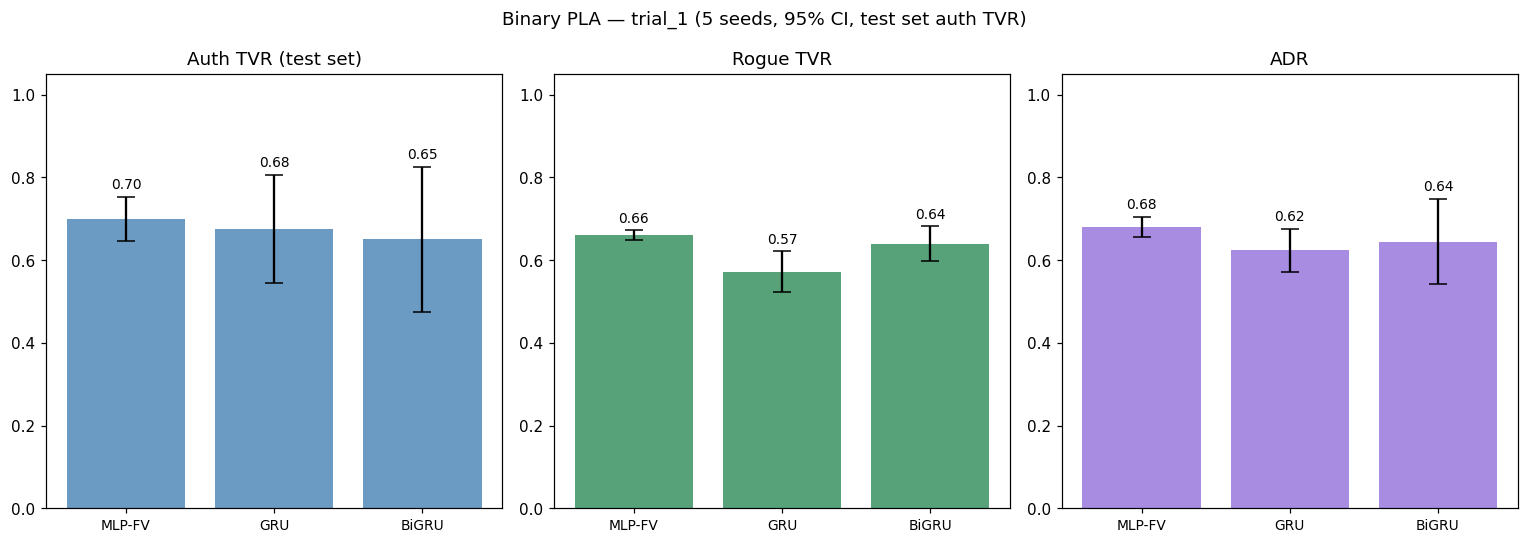

In [11]:
# Error bar chart: ADR by model
model_labels = list(models_summary.keys())
seed_adrs = []
for label, by_dev in models_summary.items():
    seed_adrs.append([np.nanmean([by_dev[d]['adr'][i] for d in devices]) for i in range(n)])

means = [np.mean(v) for v in seed_adrs]
cis   = [1.96 * np.std(v) / np.sqrt(n) for v in seed_adrs]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric_key, title, color in [
    (axes[0], 'auth',  'Auth TVR (test set)', 'steelblue'),
    (axes[1], 'rogue', 'Rogue TVR',           'seagreen'),
    (axes[2], 'adr',   'ADR',                 'mediumpurple'),
]:
    seed_vals = [
        [np.nanmean([by_dev[d][metric_key][i] for d in devices]) for i in range(n)]
        for by_dev in models_summary.values()
    ]
    ms = [np.mean(v) for v in seed_vals]
    cs = [1.96 * np.std(v) / np.sqrt(n) for v in seed_vals]
    x  = np.arange(len(model_labels))
    ax.bar(x, ms, yerr=cs, color=color, alpha=0.8, capsize=6)
    ax.set_xticks(x)
    ax.set_xticklabels(['MLP-FV', 'GRU', 'BiGRU'], fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    for i, (m, c) in enumerate(zip(ms, cs)):
        ax.text(i, m + c + 0.02, f'{m:.2f}', ha='center', fontsize=9)

plt.suptitle(f'Binary PLA — {TRIAL} (5 seeds, 95% CI, test set auth TVR)', fontsize=12)
plt.tight_layout()
plt.show()


## Per-device performance breakdown

Auth TVR and Rogue TVR broken down per authorized device (mean ± std across 5 seeds, test set).

- **Top row**: MLP-FV vs GRU-DGT — does the feature-vector model outperform the raw-DGT recurrent model per device?
- **Bottom row**: GRU-DGT vs BiGRU+SpecAugment — does bidirectionality + augmentation help, and for which devices?

Error bars show ± 1 std across the 5 seeds.


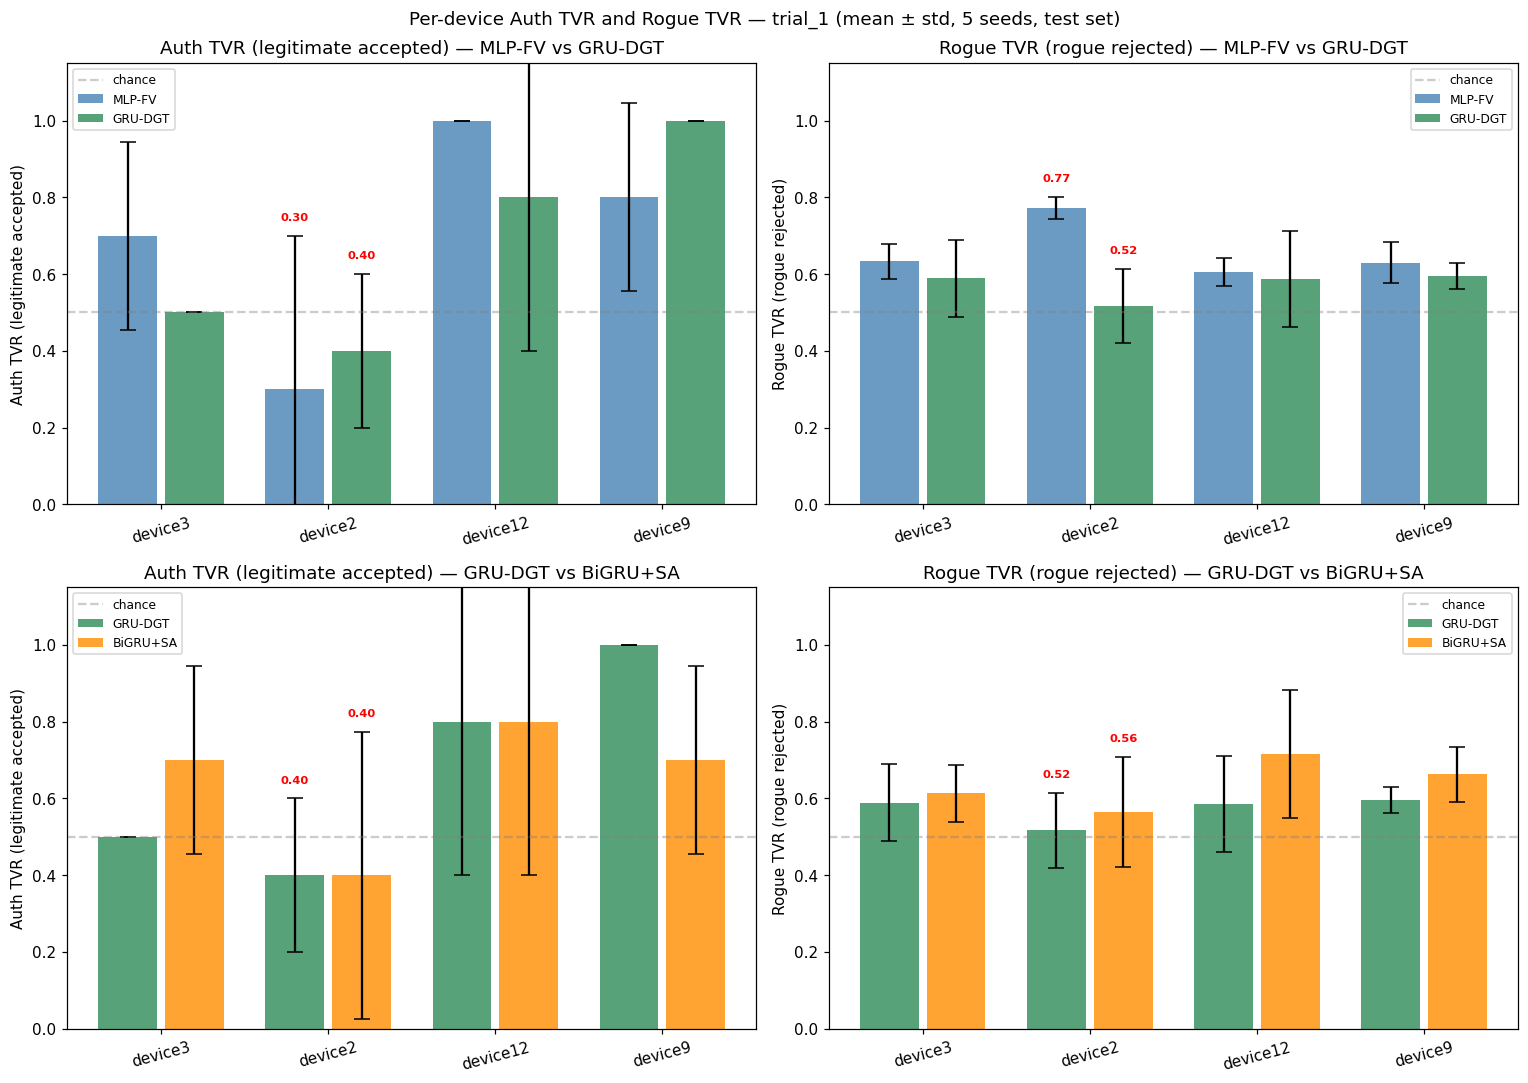

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

comparisons = [
    (axes[0, 0], axes[0, 1], by_mlp,  by_gru,   'MLP-FV',  'GRU-DGT',    'steelblue',  'seagreen'),
    (axes[1, 0], axes[1, 1], by_gru,  by_bigru,  'GRU-DGT', 'BiGRU+SA',   'seagreen',   'darkorange'),
]

x = np.arange(len(devices))
metric_titles = {'auth': 'Auth TVR (legitimate accepted)', 'rogue': 'Rogue TVR (rogue rejected)'}

# highlight_dev is annotated in red if it is an authorized device in this trial
highlight_dev = 'device2'
highlight_idx = devices.index(highlight_dev) if highlight_dev in devices else None

for ax_auth, ax_rogue, by_a, by_b, label_a, label_b, color_a, color_b in comparisons:
    for ax, metric in [(ax_auth, 'auth'), (ax_rogue, 'rogue')]:
        means_a = [np.nanmean(by_a[d][metric]) for d in devices]
        stds_a  = [np.nanstd(by_a[d][metric])  for d in devices]
        means_b = [np.nanmean(by_b[d][metric]) for d in devices]
        stds_b  = [np.nanstd(by_b[d][metric])  for d in devices]

        ax.bar(x - 0.2, means_a, 0.35, yerr=stds_a, label=label_a,
               color=color_a, alpha=0.8, capsize=5)
        ax.bar(x + 0.2, means_b, 0.35, yerr=stds_b, label=label_b,
               color=color_b, alpha=0.8, capsize=5)
        ax.set_xticks(x)
        ax.set_xticklabels(devices, rotation=15)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel(metric_titles[metric])
        ax.set_title(f'{metric_titles[metric]} — {label_a} vs {label_b}')
        ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, label='chance')
        ax.legend(fontsize=8)
        if highlight_idx is not None:
            for i, (m, s) in enumerate([(means_a[highlight_idx], stds_a[highlight_idx]),
                                         (means_b[highlight_idx], stds_b[highlight_idx])]):
                offset = -0.2 if i == 0 else 0.2
                ax.text(highlight_idx + offset, m + s + 0.04, f'{m:.2f}',
                        ha='center', fontsize=7.5, color='red', fontweight='bold')

plt.suptitle(f'Per-device Auth TVR and Rogue TVR — {TRIAL} (mean ± std, 5 seeds, test set)',
             fontsize=12)
plt.tight_layout()
plt.show()


## Statistical significance

Paired Wilcoxon signed-rank test on per-seed mean ADR values.  
With n=5 seeds the minimum achievable p-value is 0.0625 (one-sided),  
so p<0.05 is structurally impossible — this reflects the limited number of seeds available.


In [13]:
def per_seed_mean_adr(by_dev, devs):
    return [np.nanmean([by_dev[d]['adr'][i] for d in devs]) for i in range(len(SEEDS))]

adr_mlp   = per_seed_mean_adr(by_mlp,   devices)
adr_gru   = per_seed_mean_adr(by_gru,   devices)
adr_bigru = per_seed_mean_adr(by_bigru, devices)

print('Per-seed mean ADR:')
for s, a, g, b in zip(SEEDS, adr_mlp, adr_gru, adr_bigru):
    print(f'  seed={s}  MLP={a:.3f}  GRU={g:.3f}  BiGRU={b:.3f}')

print()
pairs = [
    ('BiGRU vs GRU',   adr_bigru, adr_gru),
    ('BiGRU vs MLP',   adr_bigru, adr_mlp),
    ('GRU   vs MLP',   adr_gru,   adr_mlp),
]
for label, a, b in pairs:
    try:
        stat, p = stats.wilcoxon(a, b, alternative='greater')
        diff = np.mean(a) - np.mean(b)
        print(f'{label:<22}  delta={diff:+.3f}  W={stat:.1f}  p={p:.4f}'
              f'  {"*" if p < 0.05 else "n.s. (max power with n=5 is p=0.0625)"}')
    except Exception as e:
        print(f'{label:<22}  could not compute: {e}')


Per-seed mean ADR:
  seed=42  MLP=0.711  GRU=0.676  BiGRU=0.838
  seed=7  MLP=0.699  GRU=0.512  BiGRU=0.659
  seed=13  MLP=0.650  GRU=0.615  BiGRU=0.612
  seed=99  MLP=0.645  GRU=0.666  BiGRU=0.643
  seed=2024  MLP=0.695  GRU=0.649  BiGRU=0.471

BiGRU vs GRU            delta=+0.021  W=7.0  p=0.5938  n.s. (max power with n=5 is p=0.0625)
BiGRU vs MLP            delta=-0.035  W=4.0  p=0.8438  n.s. (max power with n=5 is p=0.0625)
GRU   vs MLP            delta=-0.057  W=1.0  p=0.9688  n.s. (max power with n=5 is p=0.0625)


## Device2 performance breakdown — verified across seeds

Auth TVR for device2 is notably lower with sequence models (GRU/BiGRU) than with MLP-FV.  
This section verifies that the pattern holds consistently across all 5 independent seeds.


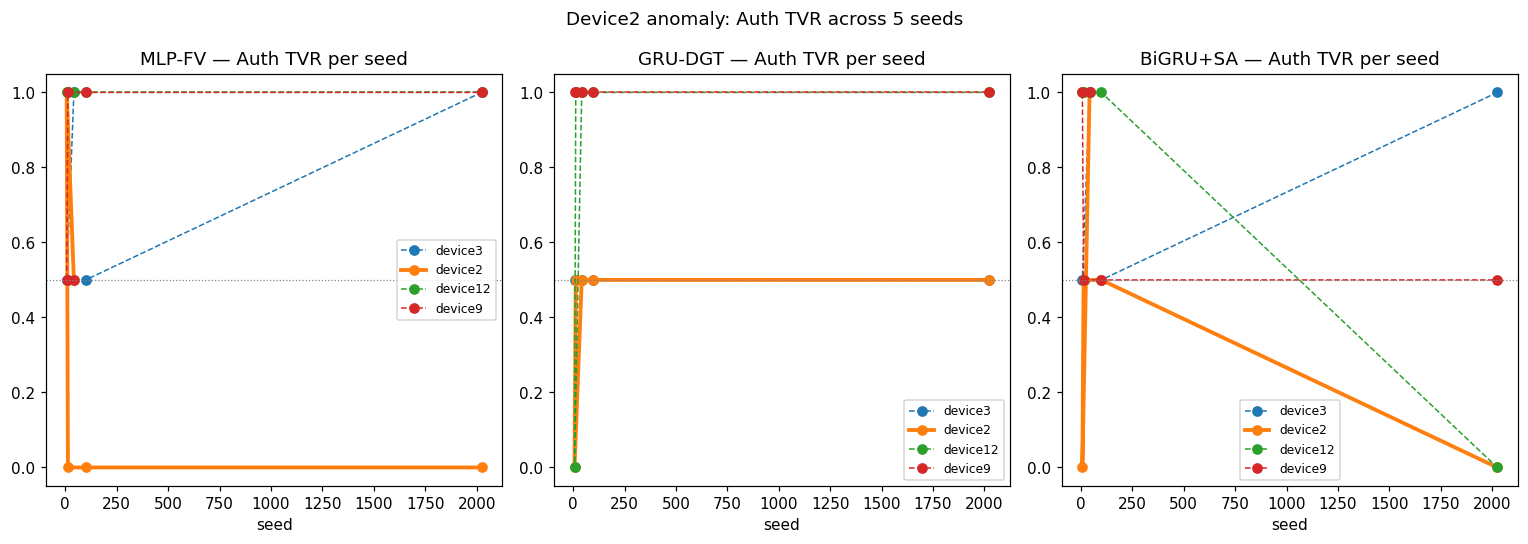


Device2 Auth TVR across seeds:
Model                  s=42 s=7 s=13 s=99 s=2024  mean +/- std
---------------------------------------------------------------------------
MLP-FV                 0.50  1.00  0.00  0.00  0.00  =>  0.300 +/- 0.400
GRU-DGT                0.50  0.00  0.50  0.50  0.50  =>  0.400 +/- 0.200
BiGRU+SpecAugment      1.00  0.00  0.50  0.50  0.00  =>  0.400 +/- 0.374


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, by_dev, label in [
    (axes[0], by_mlp,   'MLP-FV'),
    (axes[1], by_gru,   'GRU-DGT'),
    (axes[2], by_bigru, 'BiGRU+SA'),
]:
    for dev in devices:
        vals = by_dev[dev]['auth']
        x    = SEEDS
        lw   = 2.5 if dev == 'device2' else 1.0
        ls   = '-'  if dev == 'device2' else '--'
        ax.plot(x, vals, marker='o', label=dev, linewidth=lw, linestyle=ls)
    ax.set_title(f'{label} — Auth TVR per seed')
    ax.set_xlabel('seed')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='gray', lw=0.8, linestyle=':')
    ax.legend(fontsize=8)

plt.suptitle('Device2 anomaly: Auth TVR across 5 seeds', fontsize=12)
plt.tight_layout()
plt.show()

print('\nDevice2 Auth TVR across seeds:')
print(f'{"Model":<22} {" ".join(f"s={s}" for s in SEEDS)}  mean +/- std')
print('-' * 75)
for label, by_dev in models_summary.items():
    vals = by_dev['device2']['auth']
    line = '  '.join(f'{v:.2f}' for v in vals)
    print(f'{label:<22} {line}  =>  {np.nanmean(vals):.3f} +/- {np.nanstd(vals):.3f}')


## 10. LOTO evaluation — deterministic, no seeds

Leave-One-Transient-Out cross-validation.  For each authorized device A every
transient is held out exactly once as the test fingerprint, giving a single
**deterministic** auth_tvr per device (no random seed variance).

Fold design per model:
- **Test** — 1 baseline fingerprint of device A (auth_tvr measured here)
- **Val** — 1 baseline fingerprint of device A (early stopping) + 1 baseline fingerprint per other authorized device (negative class in val loss)
- **Train** — windowed remaining transients of A + windowed all other authorized devices

`n_jobs=-1` uses all CPU cores via joblib/loky.  If the cell hangs, rerun with `n_jobs=1`.

> **Note:** BiGRU is run **with** SpecAugment in LOTO — `augment=SpecAugmentDGT(**SPEC_AUGMENT)` is passed to `run_loto`.

In [15]:
from binary_pla.loto import run_loto

loto_mlp = run_loto(
    TRIAL, repr_type='fv', model_name='mlp_fv',
    epochs=EPOCHS, patience=PATIENCE, n_jobs=N_JOBS,
    augment=None,
)

[run_loto] trial_1 | fv | mlp_fv | seed=42 | n_jobs=-1
  device3: 13 folds
  device2: 13 folds
  device12: 6 folds
  device9: 13 folds
  Total folds : 45
  Val rogues  : 51 samples (4 devices)
  Test rogues : 38 samples (4 devices)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   10.0s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   11.8s
[Parallel(n_jobs=-1)]: Done  27 out of  45 | elapsed:   13.4s remaining:    8.9s
[Parallel(n_jobs=-1)]: Done  32 out of  45 | elapsed:   14.0s remaining:    5.7s
[Parallel(n_jobs=-1)]: Done  37 out of  45 | elapsed:   15.1s remaining:    3.3s
[Parallel(n_jobs=-1)]: Done  42 out of  45 | elapsed:   15.7s remaining:    1.1s



──────────────────────────────────────────────────────────────────────
  Device           Auth      ±    Rogue      ±     ADR │   Auth*   Rogue*    ADR*   thr*
  ──────────────────────────────────────────────────────────────────
  device3         0.462  0.499    0.567  0.057   0.514 │   0.615    0.447   0.531  0.365
  device2         0.385  0.487    0.848  0.071   0.616 │   0.462    0.638   0.550  0.344
  device12        0.833  0.373    0.693  0.056   0.763 │   1.000    0.575   0.787  0.370
  device9         0.846  0.361    0.626  0.081   0.736 │   0.769    0.678   0.724  0.553
  ──────────────────────────────────────────────────────────────────
  MEAN            0.631  0.430    0.683  0.066   0.657 │   0.712    0.584   0.648
  (* = optimal threshold from val)
──────────────────────────────────────────────────────────────────────


[Parallel(n_jobs=-1)]: Done  45 out of  45 | elapsed:   15.9s finished


In [16]:
loto_gru = run_loto(
    TRIAL, repr_type='dgt', model_name='gru_dgt',
    epochs=EPOCHS, patience=PATIENCE, n_jobs=N_JOBS,
    augment=None,
)

[run_loto] trial_1 | dgt | gru_dgt | seed=42 | n_jobs=-1
  device3: 13 folds
  device2: 13 folds
  device12: 6 folds
  device9: 13 folds
  Total folds : 45
  Val rogues  : 51 samples (4 devices)
  Test rogues : 38 samples (4 devices)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   24.6s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   50.5s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done  27 out of  45 | elapsed:  2.3min remaining:  1.5min
[Parallel(n_jobs=-1)]: Done  32 out of  45 | elapsed:  2.5min remaining:  1.0min
[Parallel(n_jobs=-1)]: Done  37 out of  45 | elapsed:  3.6min remaining:   46.1s
[Parallel(n_jobs=-1)]: Done  42 out of  45 | elapsed:  3.7min remaining:   15.9s
[Parallel(n_jobs=-1)]: Done  45 out of  45 | elapsed:  3.8min finished



──────────────────────────────────────────────────────────────────────
  Device           Auth      ±    Rogue      ±     ADR │   Auth*   Rogue*    ADR*   thr*
  ──────────────────────────────────────────────────────────────────
  device3         0.462  0.499    0.678  0.129   0.570 │   0.462    0.684   0.573  0.501
  device2         0.538  0.499    0.704  0.111   0.621 │   0.615    0.455   0.535  0.317
  device12        0.667  0.471    0.732  0.148   0.700 │   0.667    0.732   0.700  0.471
  device9         0.769  0.421    0.468  0.039   0.618 │   0.769    0.451   0.610  0.380
  ──────────────────────────────────────────────────────────────────
  MEAN            0.609  0.472    0.646  0.107   0.627 │   0.628    0.581   0.605
  (* = optimal threshold from val)
──────────────────────────────────────────────────────────────────────


In [17]:
augment_bigru = SpecAugmentDGT(**SPEC_AUGMENT)

loto_bigru = run_loto(
    TRIAL, repr_type='dgt', model_name='bigru_dgt',
    epochs=EPOCHS, patience=PATIENCE, n_jobs=N_JOBS,
    augment=augment_bigru,
)

[run_loto] trial_1 | dgt | bigru_dgt | seed=42 | n_jobs=-1
  device3: 13 folds
  device2: 13 folds
  device12: 6 folds
  device9: 13 folds
  Total folds : 45
  Val rogues  : 51 samples (4 devices)
  Test rogues : 38 samples (4 devices)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   58.8s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  4.4min
[Parallel(n_jobs=-1)]: Done  27 out of  45 | elapsed:  5.9min remaining:  3.9min
[Parallel(n_jobs=-1)]: Done  32 out of  45 | elapsed:  6.8min remaining:  2.8min
[Parallel(n_jobs=-1)]: Done  37 out of  45 | elapsed:  8.2min remaining:  1.8min
[Parallel(n_jobs=-1)]: Done  42 out of  45 | elapsed:  9.0min remaining:   38.7s
[Parallel(n_jobs=-1)]: Done  45 out of  45 | elapsed:  9.4min finished



──────────────────────────────────────────────────────────────────────
  Device           Auth      ±    Rogue      ±     ADR │   Auth*   Rogue*    ADR*   thr*
  ──────────────────────────────────────────────────────────────────
  device3         0.462  0.499    0.676  0.091   0.569 │   0.462    0.747   0.604  0.557
  device2         0.615  0.487    0.745  0.128   0.680 │   0.692    0.557   0.624  0.303
  device12        0.833  0.373    0.662  0.140   0.748 │   0.000    0.991   0.496  0.996
  device9         0.923  0.266    0.488  0.045   0.705 │   0.769    0.650   0.710  0.851
  ──────────────────────────────────────────────────────────────────
  MEAN            0.708  0.406    0.643  0.101   0.676 │   0.481    0.736   0.608
  (* = optimal threshold from val)
──────────────────────────────────────────────────────────────────────


### ROC curves and optimal threshold

The threshold is chosen **per device**: each binary model has its own score
distribution so a single global threshold would be suboptimal for at least one
device. `threshold_opt` is found by maximising ADR on the **val set** (val
transient of the target device + val rogue scores) and then applied blind to
the test scores.

The ROC curve below is the **val ROC** — it is the curve that was used to
select the threshold. The test result at `threshold_opt` is shown in the
summary table below.

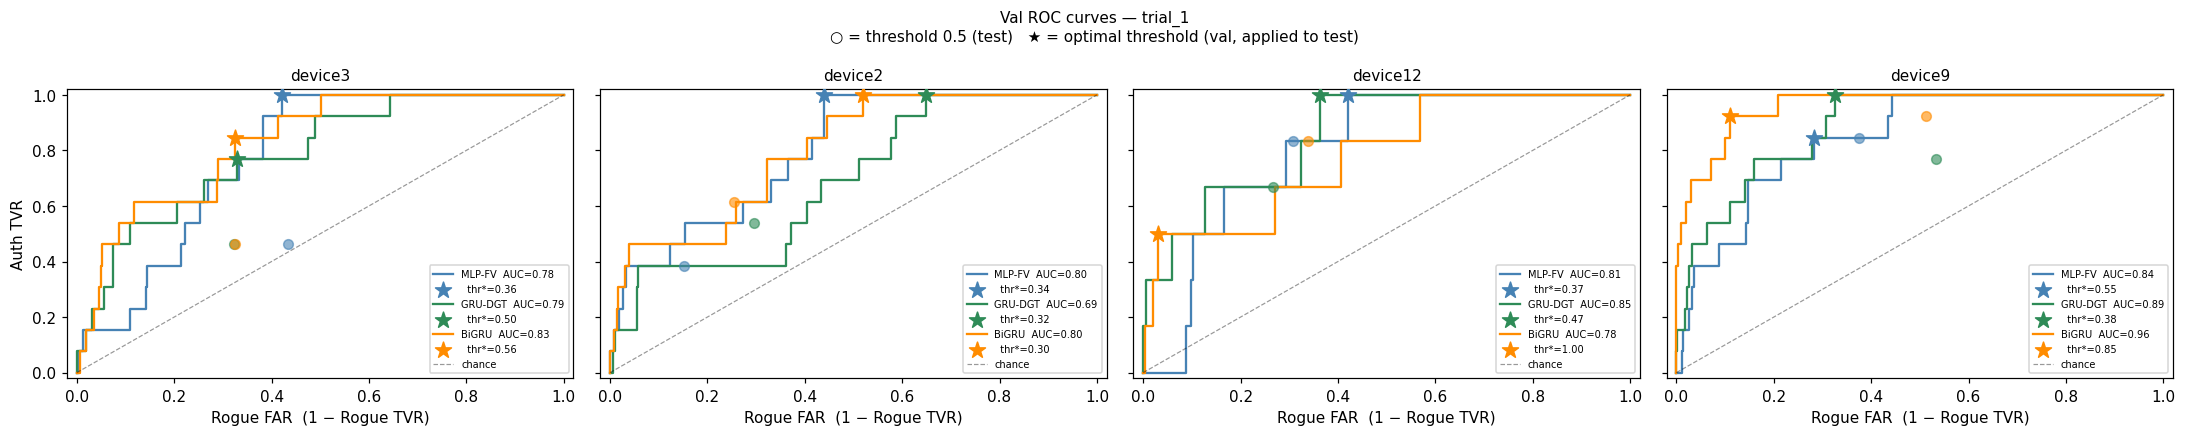


──────────────────────────────────────────────────────────────────────────────
  Optimal thresholds (val) and test results
──────────────────────────────────────────────────────────────────────────────
  Model        Device         thr*  Auth(0.5)  Auth(opt)  Rogue(0.5)  Rogue(opt)    ΔADR
  ──────────────────────────────────────────────────────────────────────────
  MLP-FV       device3       0.365      0.462      0.615       0.567       0.447  +0.017
  MLP-FV       device2       0.344      0.385      0.462       0.848       0.638  -0.067
  MLP-FV       device12      0.370      0.833      1.000       0.693       0.575  +0.024
  MLP-FV       device9       0.553      0.846      0.769       0.626       0.678  -0.012
  ──────────────────────────────────────────────────────────────────────────
  GRU-DGT      device3       0.501      0.462      0.462       0.678       0.684  +0.003
  GRU-DGT      device2       0.317      0.538      0.615       0.704       0.455  -0.086
  GRU-DGT      devic

In [18]:
from sklearn.metrics import auc as sk_auc
from binary_pla.config import TRIALS

devices = TRIALS[TRIAL]['authorized']
_loto_map = {
    'MLP-FV':  loto_mlp,
    'GRU-DGT': loto_gru,
    'BiGRU':   loto_bigru,
}
_colors = {'MLP-FV': 'steelblue', 'GRU-DGT': 'seagreen', 'BiGRU': 'darkorange'}

fig, axes = plt.subplots(1, len(devices), figsize=(5 * len(devices), 4), sharey=True)

for ax, dev in zip(axes, devices):
    for model_label, loto_res in _loto_map.items():
        d     = loto_res[dev]
        fpr   = np.array(d['fpr'])
        tpr   = np.array(d['tpr'])
        roc_auc = sk_auc(fpr, tpr)
        thr   = d['threshold_opt']

        ax.plot(fpr, tpr, color=_colors[model_label], lw=1.5,
                label=f'{model_label}  AUC={roc_auc:.2f}')

        ax.scatter(
            1 - d['rogue_tvr'],
            d['auth_tvr'],
            marker='o', s=40, color=_colors[model_label], zorder=5,
            alpha=0.6,
        )
        opt_adr = (np.array(tpr) + (1 - np.array(fpr))) / 2
        opt_idx = int(np.argmax(opt_adr))
        ax.scatter(
            fpr[opt_idx], tpr[opt_idx],
            marker='*', s=120, color=_colors[model_label], zorder=6,
            label=f'  thr*={thr:.2f}',
        )

    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4, label='chance')
    ax.set_title(dev, fontsize=10)
    ax.set_xlabel('Rogue FAR  (1 − Rogue TVR)')
    if ax is axes[0]:
        ax.set_ylabel('Auth TVR')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=6.5, loc='lower right')

plt.suptitle(
    f'Val ROC curves — {TRIAL}\n'
    f'○ = threshold 0.5 (test)   ★ = optimal threshold (val, applied to test)',
    fontsize=10,
)
plt.tight_layout()
plt.show()

# ── Threshold summary table ───────────────────────────────────────────────────
print(f'\n{"─"*78}')
print(f'  Optimal thresholds (val) and test results')
print(f'{"─"*78}')
print(f'  {"Model":<12} {"Device":<12} {"thr*":>6} '
      f'{"Auth(0.5)":>10} {"Auth(opt)":>10} '
      f'{"Rogue(0.5)":>11} {"Rogue(opt)":>11} '
      f'{"ΔADR":>7}')
print(f'  {"─"*74}')
for model_label, loto_res in _loto_map.items():
    for dev in devices:
        d = loto_res[dev]
        delta_adr = d['adr_opt'] - d['adr']
        print(f'  {model_label:<12} {dev:<12} {d["threshold_opt"]:>6.3f} '
              f'{d["auth_tvr"]:>10.3f} {d["auth_tvr_opt"]:>10.3f} '
              f'{d["rogue_tvr"]:>11.3f} {d["rogue_tvr_opt"]:>11.3f} '
              f'{delta_adr:>+7.3f}')
    print(f'  {"─"*74}')


────────────────────────────────────────────────────────────────────────────────
  LOTO results — trial_1  (deterministic, threshold=0.5)
────────────────────────────────────────────────────────────────────────────────
  Model              Device         Auth TVR   ±std  Rogue TVR   ±std      ADR  Folds
  ────────────────────────────────────────────────────────────────────────────
  MLP-FV             device3           0.462  0.499      0.567  0.057    0.514     13
  MLP-FV             device2           0.385  0.487      0.848  0.071    0.616     13
  MLP-FV             device12          0.833  0.373      0.693  0.056    0.763      6
  MLP-FV             device9           0.846  0.361      0.626  0.081    0.736     13
    MEAN                               0.631             0.683           0.657
  ────────────────────────────────────────────────────────────────────────────
  GRU-DGT            device3           0.462  0.499      0.678  0.129    0.570     13
  GRU-DGT            device

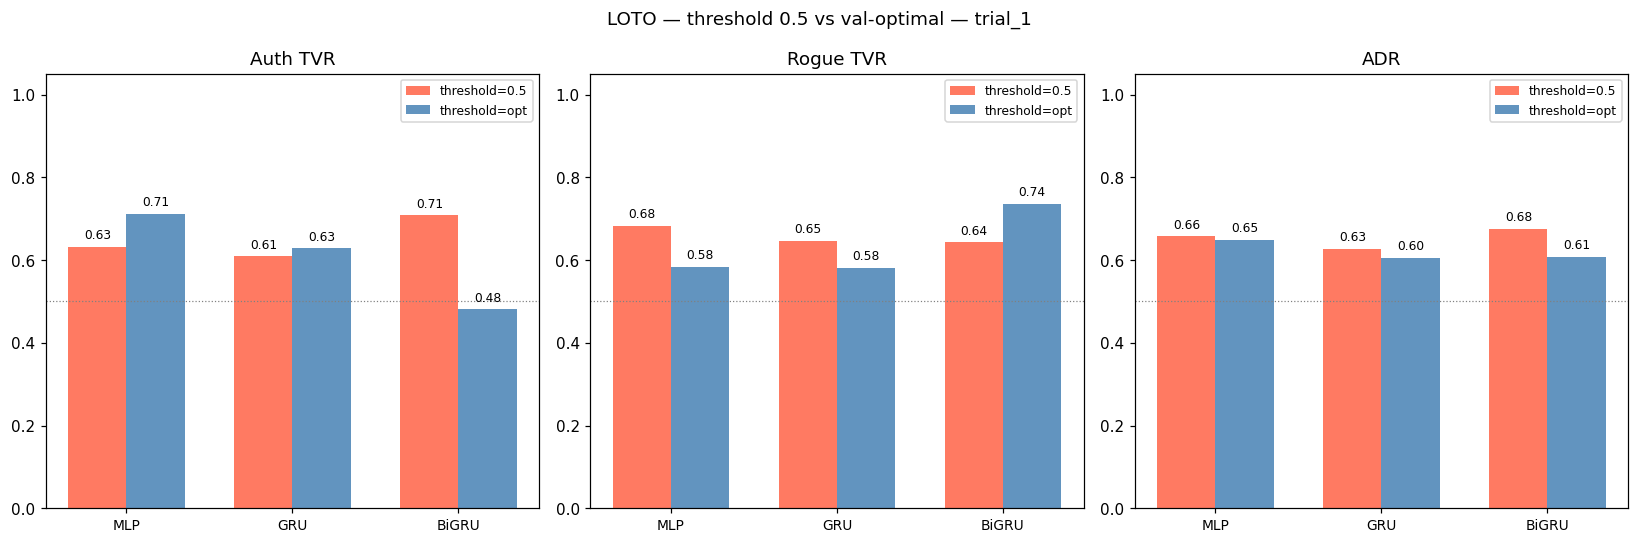

In [19]:
from binary_pla.config import TRIALS

devices = TRIALS[TRIAL]['authorized']

loto_results = {
    'MLP-FV':  loto_mlp,
    'GRU-DGT': loto_gru,
    'BiGRU':   loto_bigru,
}

# ── Per-device table ──────────────────────────────────────────────────────────
print(f'\n{"─"*80}')
print(f'  LOTO results — {TRIAL}  (deterministic, threshold=0.5)')
print(f'{"─"*80}')
print(f'  {"Model":<18} {"Device":<12} {"Auth TVR":>10} {"±std":>6} '
      f'{"Rogue TVR":>10} {"±std":>6} {"ADR":>8} {"Folds":>6}')
print(f'  {"─"*76}')
for model_label, res in loto_results.items():
    for dev in devices:
        d = res[dev]
        print(f'  {model_label:<18} {dev:<12} '
              f'{d["auth_tvr"]:>10.3f} {d["auth_tvr_std"]:>6.3f} '
              f'{d["rogue_tvr"]:>10.3f} {d["rogue_tvr_std"]:>6.3f} '
              f'{d["adr"]:>8.3f} {d["n_folds"]:>6}')
    s = res['_summary']
    print(f'  {"  MEAN":<18} {"":12} '
          f'{s["mean_auth_tvr"]:>10.3f} {"":>6} '
          f'{s["mean_rogue_tvr"]:>10.3f} {"":>6} '
          f'{s["mean_adr"]:>8.3f}')
    print(f'  {"─"*76}')

# ── Summary: threshold=0.5 vs optimal ─────────────────────────────────────────
print(f'\n{"─"*60}')
print(f'  Summary — LOTO threshold comparison')
print(f'{"─"*60}')
print(f'  {"Model":<18} {"Threshold":>10} {"Auth TVR":>10} {"Rogue TVR":>10} {"ADR":>8}')
print(f'  {"─"*56}')
for model_label, res in loto_results.items():
    s = res['_summary']
    print(f'  {model_label:<18} {"0.5":>10} '
          f'{s["mean_auth_tvr"]:>10.3f} '
          f'{s["mean_rogue_tvr"]:>10.3f} '
          f'{s["mean_adr"]:>8.3f}')
    print(f'  {"":18} {"opt (val)":>10} '
          f'{s["mean_auth_tvr_opt"]:>10.3f} '
          f'{s["mean_rogue_tvr_opt"]:>10.3f} '
          f'{s["mean_adr_opt"]:>8.3f}')
    print(f'  {"─"*56}')

# ── Bar chart ─────────────────────────────────────────────────────────────────
model_labels = list(loto_results.keys())
x = np.arange(len(model_labels))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, keys, title in [
    (axes[0], ('auth_tvr',  'auth_tvr_opt'),  'Auth TVR'),
    (axes[1], ('rogue_tvr', 'rogue_tvr_opt'), 'Rogue TVR'),
    (axes[2], ('adr',       'adr_opt'),        'ADR'),
]:
    key_05, key_opt = keys
    vals_05  = [loto_results[m]['_summary'][f'mean_{key_05}']  for m in model_labels]
    vals_opt = [loto_results[m]['_summary'][f'mean_{key_opt}'] for m in model_labels]

    ax.bar(x - w/2, vals_05,  w, label='threshold=0.5', color='tomato',    alpha=0.85)
    ax.bar(x + w/2, vals_opt, w, label='threshold=opt', color='steelblue', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(['MLP', 'GRU', 'BiGRU'], fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.axhline(0.5, color='gray', linestyle=':', lw=0.8)
    ax.legend(fontsize=8)
    for i, (v1, v2) in enumerate(zip(vals_05, vals_opt)):
        ax.text(i - w/2, v1 + 0.02, f'{v1:.2f}', ha='center', fontsize=8)
        ax.text(i + w/2, v2 + 0.02, f'{v2:.2f}', ha='center', fontsize=8)

plt.suptitle(f'LOTO — threshold 0.5 vs val-optimal — {TRIAL}', fontsize=12)
plt.tight_layout()
plt.show()

## EER — BiGRU LOTO

Equal Error Rate: the operating point where FAR = FRR, i.e. `fpr ≈ 1 − tpr`.
Computed from the val ROC arrays already saved by the LOTO run — no extra evaluation needed.

EER is the standard single-number summary in the biometrics literature (speaker verification,
face recognition, fingerprint authentication) and makes these results directly comparable to
prior PLA work.

In [20]:
def compute_eer(fpr, tpr):
    """EER at the point where |FPR - FRR| is minimised. Lower = better; 0.5 = chance."""
    fpr, tpr = np.array(fpr), np.array(tpr)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float((fpr[idx] + fnr[idx]) / 2)

_eer_devices = TRIALS[TRIAL]['authorized']

print(f'EER — BiGRU LOTO  ({TRIAL}, val ROC)')
print(f'{"─"*38}')
print(f'  {"Device":<12} {"EER":>8}   {"AUC":>6}')
print(f'  {"─"*30}')

from sklearn.metrics import auc as sk_auc

eer_vals = []
for dev in _eer_devices:
    d   = loto_bigru[dev]
    eer = compute_eer(d['fpr'], d['tpr'])
    auc = sk_auc(np.array(d['fpr']), np.array(d['tpr']))
    eer_vals.append(eer)
    print(f'  {dev:<12} {eer:>8.3f}   {auc:>6.3f}')

print(f'  {"─"*30}')
print(f'  {"Mean":<12} {np.mean(eer_vals):>8.3f} ± {np.std(eer_vals):.3f}')
print(f'\nNote: EER < 0.5 means the model has discriminative power above chance.')
print(f'      EER = 0.5 is the random baseline.')

EER — BiGRU LOTO  (trial_1, val ROC)
──────────────────────────────────────
  Device            EER      AUC
  ──────────────────────────────
  device3         0.299    0.829
  device2         0.354    0.798
  device12        0.302    0.784
  device9         0.094    0.958
  ──────────────────────────────
  Mean            0.262 ± 0.100

Note: EER < 0.5 means the model has discriminative power above chance.
      EER = 0.5 is the random baseline.


## Save results

In [21]:
from binary_pla.config import NB02_ID, TRIALS
from binary_pla.results_io import save_results, load_results, results_exist

_authorized = TRIALS[TRIAL]["authorized"]

def _seed_run_to_dict(seed_run, authorized_devices):
    entry = {"seed": int(seed_run["seed"])}
    for dev in authorized_devices:
        m = seed_run["metrics"][dev]
        entry[dev] = {
            "auth_tvr":   None if (isinstance(m["auth_tvr"], float) and np.isnan(m["auth_tvr"]))
                          else float(m["auth_tvr"]),
            "rogue_tvr":  float(m["rogue_tvr"]),
            "adr":        None if (isinstance(m["adr"], float) and np.isnan(m["adr"]))
                          else float(m["adr"]),
            "n_test_pos": int(m["n_test_pos"]),
        }
    return entry

def _loto_to_dict(loto_res, authorized_devices):
    out = {}
    for dev in authorized_devices:
        d = loto_res[dev]
        out[dev] = {
            "auth_tvr":      float(d["auth_tvr"]),
            "auth_tvr_std":  float(d["auth_tvr_std"]),
            "rogue_tvr":     float(d["rogue_tvr"]),
            "rogue_tvr_std": float(d["rogue_tvr_std"]),
            "adr":           float(d["adr"]),
            "n_folds":       int(d["n_folds"]),
            "threshold_opt": float(d["threshold_opt"]),
            "auth_tvr_opt":  float(d["auth_tvr_opt"]),
            "rogue_tvr_opt": float(d["rogue_tvr_opt"]),
            "adr_opt":       float(d["adr_opt"]),
            "fpr": [float(v) for v in d["fpr"]],
            "tpr": [float(v) for v in d["tpr"]],
        }
    s = loto_res["_summary"]
    out["_summary"] = {k: float(v) for k, v in s.items()}
    return out

# ── Merge with any previously saved results ───────────────────────────────────
if results_exist(NB02_ID, TRIAL):
    _, results_payload = load_results(NB02_ID, TRIAL)
else:
    results_payload = {}

# ── Add seed-based results if available in this session ───────────────────────
try:
    results_payload["mlp_fv"]    = {"per_seed": [_seed_run_to_dict(r, _authorized) for r in res_mlp]}
    results_payload["gru_dgt"]   = {"per_seed": [_seed_run_to_dict(r, _authorized) for r in res_gru]}
    results_payload["bigru_dgt"] = {"per_seed": [_seed_run_to_dict(r, _authorized) for r in res_bigru]}
    print("Seed-based results included.")
except NameError:
    print("Seed-based results not in session — keeping previously saved values.")

# ── Add LOTO results if available in this session ─────────────────────────────
try:
    results_payload["loto"] = {
        "mlp_fv":    _loto_to_dict(loto_mlp,   _authorized),
        "gru_dgt":   _loto_to_dict(loto_gru,   _authorized),
        "bigru_dgt": _loto_to_dict(loto_bigru, _authorized),
    }
    print("LOTO results included.")
except NameError:
    print("LOTO results not in session — keeping previously saved values.")

save_results(
    NB02_ID, TRIAL, results_payload,
    extra_meta={
        "seeds":    list(SEEDS),
        "epochs":   EPOCHS,
        "patience": PATIENCE,
    },
)

[results_io] loaded nb02_dl_honest/trial_1  (saved 2026-06-03, git 75dff0b)
Seed-based results included.
LOTO results included.
[results_io] saved → /Users/matteocampagnaro/Documents/pla-binary-analysis/results/nb02_dl_honest_trial_1.json


'/Users/matteocampagnaro/Documents/pla-binary-analysis/results/nb02_dl_honest_trial_1.json'

## Run remaining trials

Run this section after completing trial_1 above. Each additional trial trains all three
models (MLP-FV × 5 seeds, GRU-DGT × 5 seeds, BiGRU × 5 seeds) plus all three LOTO
evaluations, and saves results to a separate JSON per trial.

Estimated time per trial: same as trial_1 (~30–60 min depending on hardware).

`TRIALS_TO_RUN` is defined in `binary_pla/config.py`.

In [22]:
from binary_pla.config import TRIALS_TO_RUN

for _trial in TRIALS_TO_RUN:
    if _trial == TRIAL:
        print(f'Skipping {_trial} — already run above.')
        continue

    print(f'\n{"="*60}')
    print(f'  {_trial.upper()}')
    print(f'{"="*60}')

    # ── Seed-based evaluation ─────────────────────────────────────────────────
    _res_mlp   = run_multi_seed('fv',  'mlp_fv',    SEEDS, trial=_trial)
    _res_gru   = run_multi_seed('dgt', 'gru_dgt',   SEEDS, trial=_trial)
    _res_bigru = run_multi_seed('dgt', 'bigru_dgt', SEEDS,
                                augment=SpecAugmentDGT(**SPEC_AUGMENT), trial=_trial)

    # ── LOTO ─────────────────────────────────────────────────────────────────
    _loto_mlp   = run_loto(_trial, repr_type='fv',  model_name='mlp_fv',
                           epochs=EPOCHS, patience=PATIENCE, n_jobs=N_JOBS)
    _loto_gru   = run_loto(_trial, repr_type='dgt', model_name='gru_dgt',
                           epochs=EPOCHS, patience=PATIENCE, n_jobs=N_JOBS)
    _loto_bigru = run_loto(_trial, repr_type='dgt', model_name='bigru_dgt',
                           epochs=EPOCHS, patience=PATIENCE, n_jobs=N_JOBS,
                           augment=SpecAugmentDGT(**SPEC_AUGMENT))

    # ── Save ──────────────────────────────────────────────────────────────────
    _auth = TRIALS[_trial]['authorized']
    _payload = {
        'mlp_fv':    {'per_seed': [_seed_run_to_dict(r, _auth) for r in _res_mlp]},
        'gru_dgt':   {'per_seed': [_seed_run_to_dict(r, _auth) for r in _res_gru]},
        'bigru_dgt': {'per_seed': [_seed_run_to_dict(r, _auth) for r in _res_bigru]},
        'loto': {
            'mlp_fv':    _loto_to_dict(_loto_mlp,   _auth),
            'gru_dgt':   _loto_to_dict(_loto_gru,   _auth),
            'bigru_dgt': _loto_to_dict(_loto_bigru, _auth),
        },
    }
    save_results(NB02_ID, _trial, _payload,
                 extra_meta={'seeds': list(SEEDS), 'epochs': EPOCHS, 'patience': PATIENCE})
    print(f'  ✓ {_trial} saved.')

print('\nAll trials complete.')

Skipping trial_1 — already run above.

  TRIAL_2

--- seed=42 ---
[load_trial_honest] trial_2 | repr=fv | seed=42
  train: 390 windowed samples from 39 transients
  val:   9 baseline samples  |  test: 9 baseline samples  |  rogue: 77 baseline samples
  Auth TVR=0.333  Rogue TVR=0.751  ADR=0.542

--- seed=7 ---
[load_trial_honest] trial_2 | repr=fv | seed=7
  train: 390 windowed samples from 39 transients
  val:   9 baseline samples  |  test: 9 baseline samples  |  rogue: 77 baseline samples
  Auth TVR=0.833  Rogue TVR=0.758  ADR=0.795

--- seed=13 ---
[load_trial_honest] trial_2 | repr=fv | seed=13
  train: 390 windowed samples from 39 transients
  val:   9 baseline samples  |  test: 9 baseline samples  |  rogue: 77 baseline samples
  Auth TVR=0.500  Rogue TVR=0.781  ADR=0.641

--- seed=99 ---
[load_trial_honest] trial_2 | repr=fv | seed=99
  train: 390 windowed samples from 39 transients
  val:   9 baseline samples  |  test: 9 baseline samples  |  rogue: 77 baseline samples
  Auth TVR

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   13.4s
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done  40 out of  57 | elapsed:   16.8s remaining:    7.2s
[Parallel(n_jobs=-1)]: Done  46 out of  57 | elapsed:   18.2s remaining:    4.3s
[Parallel(n_jobs=-1)]: Done  52 out of  57 | elapsed:   19.4s remaining:    1.9s
[Parallel(n_jobs=-1)]: Done  57 out of  57 | elapsed:   20.1s finished



──────────────────────────────────────────────────────────────────────
  Device           Auth      ±    Rogue      ±     ADR │   Auth*   Rogue*    ADR*   thr*
  ──────────────────────────────────────────────────────────────────
  device10        0.333  0.471    0.842  0.066   0.588 │   0.500    0.482   0.491  0.409
  device6         0.769  0.421    0.721  0.080   0.745 │   0.769    0.696   0.733  0.443
  device12        0.500  0.500    0.781  0.052   0.640 │   0.833    0.697   0.765  0.351
  device3         0.615  0.487    0.802  0.150   0.709 │   0.769    0.662   0.716  0.297
  device11        0.500  0.500    0.868  0.037   0.684 │   0.500    0.794   0.647  0.468
  device1         0.615  0.487    0.561  0.044   0.588 │   0.615    0.500   0.558  0.416
  ──────────────────────────────────────────────────────────────────
  MEAN            0.556  0.478    0.762  0.072   0.659 │   0.665    0.639   0.652
  (* = optimal threshold from val)
──────────────────────────────────────────────────

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   31.1s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done  40 out of  57 | elapsed:  4.6min remaining:  2.0min
[Parallel(n_jobs=-1)]: Done  46 out of  57 | elapsed:  5.5min remaining:  1.3min
[Parallel(n_jobs=-1)]: Done  52 out of  57 | elapsed:  6.2min remaining:   35.7s
[Parallel(n_jobs=-1)]: Done  57 out of  57 | elapsed:  6.8min finished



──────────────────────────────────────────────────────────────────────
  Device           Auth      ±    Rogue      ±     ADR │   Auth*   Rogue*    ADR*   thr*
  ──────────────────────────────────────────────────────────────────
  device10        0.333  0.471    0.715  0.204   0.524 │   0.167    0.803   0.485  0.524
  device6         0.769  0.421    0.686  0.052   0.728 │   0.769    0.721   0.745  0.964
  device12        0.667  0.471    0.798  0.137   0.732 │   0.667    0.711   0.689  0.417
  device3         0.385  0.487    0.656  0.117   0.520 │   0.615    0.488   0.552  0.266
  device11        0.500  0.500    0.706  0.177   0.603 │   0.333    0.908   0.621  0.623
  device1         0.231  0.421    0.662  0.174   0.446 │   0.308    0.561   0.434  0.403
  ──────────────────────────────────────────────────────────────────
  MEAN            0.481  0.462    0.704  0.143   0.592 │   0.476    0.698   0.587
  (* = optimal threshold from val)
──────────────────────────────────────────────────

...


──────────────────────────────────────────────────────────────────────
  Device           Auth      ±    Rogue      ±     ADR │   Auth*   Rogue*    ADR*   thr*
  ──────────────────────────────────────────────────────────────────
  device1         0.538  0.499    0.517  0.128   0.528 │   0.538    0.388   0.463  0.398
  device10        0.333  0.471    0.800  0.095   0.567 │   0.500    0.493   0.497  0.345
  device9         0.385  0.487    0.674  0.137   0.529 │   0.385    0.652   0.518  0.489
  device8         0.538  0.499    0.868  0.092   0.703 │   0.615    0.692   0.654  0.414
  device12        0.500  0.500    0.793  0.054   0.647 │   0.167    0.827   0.497  0.553
  device11        0.500  0.500    0.893  0.079   0.697 │   0.500    0.880   0.690  0.497
  device6         0.769  0.421    0.846  0.064   0.808 │   0.769    0.858   0.814  0.557
  device7         0.308  0.462    0.818  0.066   0.563 │   0.769    0.572   0.671  0.274
  ────────────────────────────────────────────────────────

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   50.2s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:  7.0min
[Parallel(n_jobs=-1)]: Done  69 out of  83 | elapsed: 11.6min remaining:  2.4min
[Parallel(n_jobs=-1)]: Done  78 out of  83 | elapsed: 12.4min remaining:   47.8s
[Parallel(n_jobs=-1)]: Done  83 out of  83 | elapsed: 13.7min finished



──────────────────────────────────────────────────────────────────────
  Device           Auth      ±    Rogue      ±     ADR │   Auth*   Rogue*    ADR*   thr*
  ──────────────────────────────────────────────────────────────────
  device1         0.462  0.499    0.625  0.176   0.543 │   0.462    0.649   0.555  0.509
  device10        0.333  0.471    0.693  0.164   0.513 │   0.333    0.607   0.470  0.482
  device9         0.538  0.499    0.760  0.198   0.649 │   0.462    0.785   0.623  0.537
  device8         0.462  0.499    0.794  0.165   0.628 │   0.615    0.646   0.631  0.399
  device12        0.833  0.373    0.873  0.067   0.853 │   0.833    0.860   0.847  0.432
  device11        0.333  0.471    0.787  0.088   0.560 │   0.500    0.667   0.583  0.444
  device6         0.846  0.361    0.834  0.072   0.840 │   0.846    0.892   0.869  0.978
  device7         0.385  0.487    0.803  0.124   0.594 │   0.462    0.711   0.586  0.383
  ────────────────────────────────────────────────────────

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed: 11.1min
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 14.8min
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed: 17.0min
[Parallel(n_jobs=-1)]: Done  69 out of  83 | elapsed: 27.3min remaining:  5.5min
[Parallel(n_jobs=-1)]: Done  78 out of  83 | elapsed: 30.1min remaining:  1.9min
[Parallel(n_jobs=-1)]: Done  83 out of  83 | elapsed: 31.0min finished



──────────────────────────────────────────────────────────────────────
  Device           Auth      ±    Rogue      ±     ADR │   Auth*   Rogue*    ADR*   thr*
  ──────────────────────────────────────────────────────────────────
  device1         0.538  0.499    0.477  0.167   0.508 │   0.077    0.951   0.514  0.975
  device10        0.667  0.471    0.827  0.082   0.747 │   0.667    0.840   0.753  0.539
  device9         0.692  0.462    0.729  0.145   0.711 │   0.692    0.622   0.657  0.285
  device8         0.231  0.421    0.911  0.090   0.571 │   0.385    0.834   0.609  0.339
  device12        0.667  0.471    0.880  0.101   0.773 │   0.500    0.913   0.707  0.691
  device11        0.500  0.500    0.880  0.135   0.690 │   0.500    0.800   0.650  0.423
  device6         1.000  0.000    0.831  0.045   0.915 │   0.615    0.966   0.791  0.997
  device7         0.692  0.462    0.818  0.156   0.755 │   0.692    0.775   0.734  0.450
  ────────────────────────────────────────────────────────